In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from kneed import KneeLocator
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram, inconsistent
from sklearn.decomposition import PCA

# Loading and Inspection

In [164]:
customers_df = pd.read_csv("datasets/smartcart_customers.csv")

In [165]:
customers_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [166]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [167]:
customers_df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.009375,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.096391,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000


# Preprocessing 

In [168]:
X_cleaned = customers_df

### Handling duplicates

In [169]:
X_cleaned.duplicated().sum()

np.int64(0)

No duplicates detected

### Removing unnecessary columns

Id of customer has no influence on his behavior 

In [170]:
X_cleaned = customers_df.drop(
    columns=["ID"]
)

### Removing inconsistencies in String features

In [171]:
string_columns = [
    "Education",
    "Marital_Status",
    "Dt_Customer"
]

for column in string_columns:
    print(f"{column} values: ")
    print(X_cleaned[column].unique())

Education values: 
['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
Marital_Status values: 
['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']
Dt_Customer values: 
['04-09-2012' '08-03-2014' '21-08-2013' '10-02-2014' '19-01-2014'
 '09-09-2013' '13-11-2012' '08-05-2013' '06-06-2013' '13-03-2014'
 '15-11-2013' '10-10-2012' '24-11-2012' '24-12-2012' '31-08-2012'
 '28-03-2013' '03-11-2012' '08-08-2012' '06-01-2013' '23-12-2012'
 '11-01-2014' '18-03-2013' '02-01-2013' '27-05-2013' '20-02-2013'
 '31-05-2013' '22-11-2013' '22-05-2014' '11-05-2013' '29-10-2012'
 '29-08-2013' '31-12-2013' '02-09-2013' '11-02-2014' '01-02-2013'
 '29-04-2013' '12-03-2013' '05-11-2013' '02-10-2013' '28-06-2014'
 '09-11-2012' '24-05-2013' '01-01-2014' '08-11-2012' '12-05-2014'
 '11-08-2012' '07-06-2014' '12-06-2013' '19-11-2012' '02-04-2013'
 '28-04-2014' '17-06-2013' '03-03-2014' '04-07-2013' '07-09-2012'
 '18-02-2013' '11-06-2013' '06-12-2013' '21-05-2013' '11-05-2014'
 '19-03-2014' '27-09

No inconsistency detected in Education and Marital_Status while Dt_Customer has to be converted to some other format in feature engineering.

### Handling Missing values

In [172]:
X_cleaned.isnull().sum()

Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [173]:
X_cleaned["Income"] = X_cleaned["Income"].fillna(
    X_cleaned["Income"].median()
)

# Feature Engineering

In [174]:
X_engineered = X_cleaned

### Deriving new features

There are two date features Year_Birth and Dt_Customer which have to be encoded to numeric format.

In [175]:
def cal_age(year_birth):
    return datetime.now().year - year_birth

X_engineered["Age"] = X_engineered["Year_Birth"].map(
    lambda year_birth: cal_age(year_birth)
)

In [176]:
# Converting String date to DateTime
X_engineered["Dt_Customer"] = pd.to_datetime(X_engineered["Dt_Customer"], dayfirst=True)

ref_date = datetime.now()

X_engineered["Customer_Tenure_Days"] = (ref_date - X_engineered["Dt_Customer"]).dt.days

Customer spendings in various categories have separate columns. We can combine to make one spending column.

In [177]:
X_engineered["Total_Spending"] = X_engineered["MntWines"] + X_engineered["MntFruits"] + X_engineered["MntMeatProducts"] + X_engineered["MntFishProducts"] + X_engineered["MntSweetProducts"] + X_engineered["MntGoldProds"]

KidHome and TeenHome can be combined to proudce ChildrenHome feature.

In [178]:
X_engineered["Children_Home"] = X_engineered["Kidhome"] + X_engineered["Teenhome"]

### Transforming features

Both Education and Marital_Status have categories which can be merged for clarity and simplification.

In [179]:
print(X_engineered["Education"].value_counts())
print(X_engineered["Marital_Status"].value_counts())

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [180]:
X_engineered["Education"] = X_engineered["Education"].replace(
    {
        "Basic": "Undergraduate",
        "2n Cycle": "Undergraduate",
        "Master": "Graduate",
        "Graduation": "Graduate",
        "PhD": "Postgraduate"
    }
)

In [181]:
X_engineered["Marital_Status"] = X_engineered["Marital_Status"].replace(
    {
        "Together": "Married",
        "Divorced": "Single",
        "Widow": "Single",
        "Alone": "Single",
        "Absurd": "Single",
        "YOLO": "Single"
    }
)

In [182]:
print(X_engineered["Education"].value_counts())
print(X_engineered["Marital_Status"].value_counts())

Education
Graduate         1497
Postgraduate      486
Undergraduate     257
Name: count, dtype: int64
Marital_Status
Married    1444
Single      796
Name: count, dtype: int64


### Selecting features

In [183]:
X_engineered.columns

Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Children_Home'],
      dtype='object')

In [184]:
X_engineered = X_engineered.drop(
    columns=[
        "Year_Birth",
        "Dt_Customer",
        "Kidhome",
        "Teenhome",
        "MntWines",
        "MntFruits",
        "MntMeatProducts",
        "MntFishProducts",
        "MntSweetProducts",
        "MntGoldProds",
    ]
)

### Encoding

In [185]:
X_engineered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Education             2240 non-null   object 
 1   Marital_Status        2240 non-null   object 
 2   Income                2240 non-null   float64
 3   Recency               2240 non-null   int64  
 4   NumDealsPurchases     2240 non-null   int64  
 5   NumWebPurchases       2240 non-null   int64  
 6   NumCatalogPurchases   2240 non-null   int64  
 7   NumStorePurchases     2240 non-null   int64  
 8   NumWebVisitsMonth     2240 non-null   int64  
 9   Complain              2240 non-null   int64  
 10  Response              2240 non-null   int64  
 11  Age                   2240 non-null   int64  
 12  Customer_Tenure_Days  2240 non-null   int64  
 13  Total_Spending        2240 non-null   int64  
 14  Children_Home         2240 non-null   int64  
dtypes: float64(1), int64(

In [186]:
oe = OrdinalEncoder(
    categories=[
        ["Undergraduate", "Graduate", "Postgraduate"],
        ["Single", "Married"]
    ]
)

X_engineered[["Education", "Marital_Status"]] = oe.fit_transform(X_engineered[["Education", "Marital_Status"]])

### Handling outliers

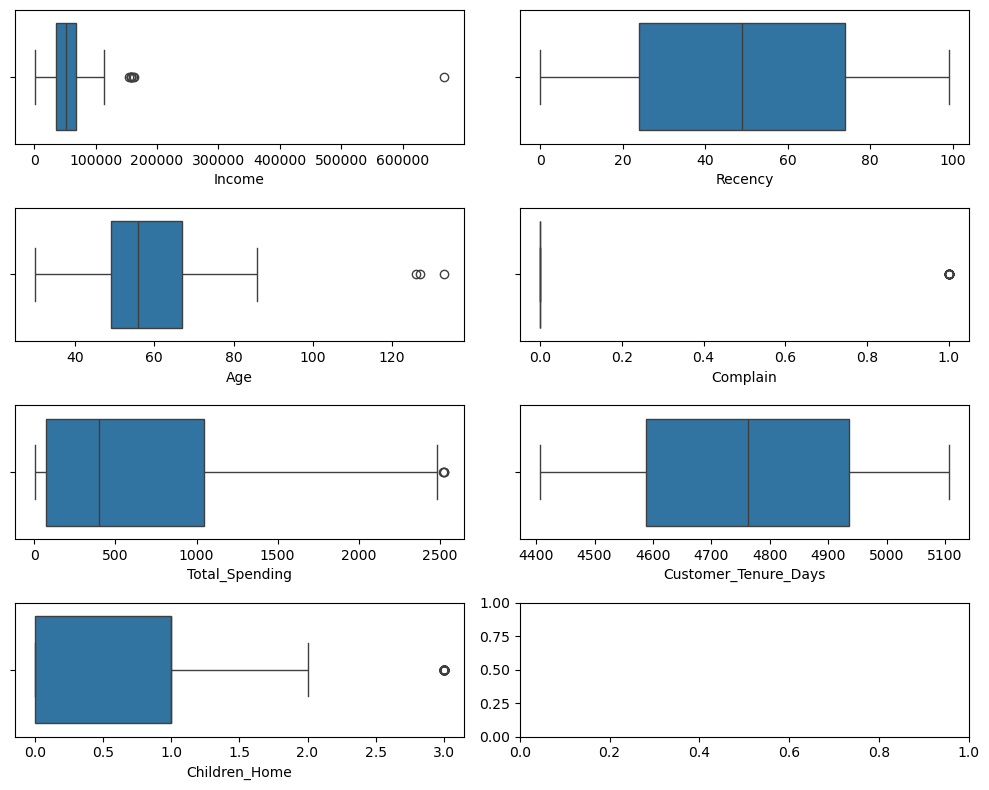

In [187]:
cols = [
        "Income",
        "Recency",
        "Age",
        "Complain",
        "Total_Spending",
        "Customer_Tenure_Days",
        "Children_Home",
    ]

fig, axes = plt.subplots(4, 2, figsize=(10, 8))

axes = axes.flatten()

for i in range(0, 7):
    sns.boxplot(
        data=X_engineered,
        x=cols[i],
        ax=axes[i]
    )

plt.tight_layout()

Income and Age have outliers.

In [188]:
print("Original points:", X_engineered.shape)
X_engineered = X_engineered.query("Income < 600000 & Age < 120").reset_index(drop=True)
print("Post outlier removal points:", X_engineered.shape)

Original points: (2240, 15)
Post outlier removal points: (2236, 15)


### Heatmap

In [189]:
corr = X_engineered.corr()

<Axes: >

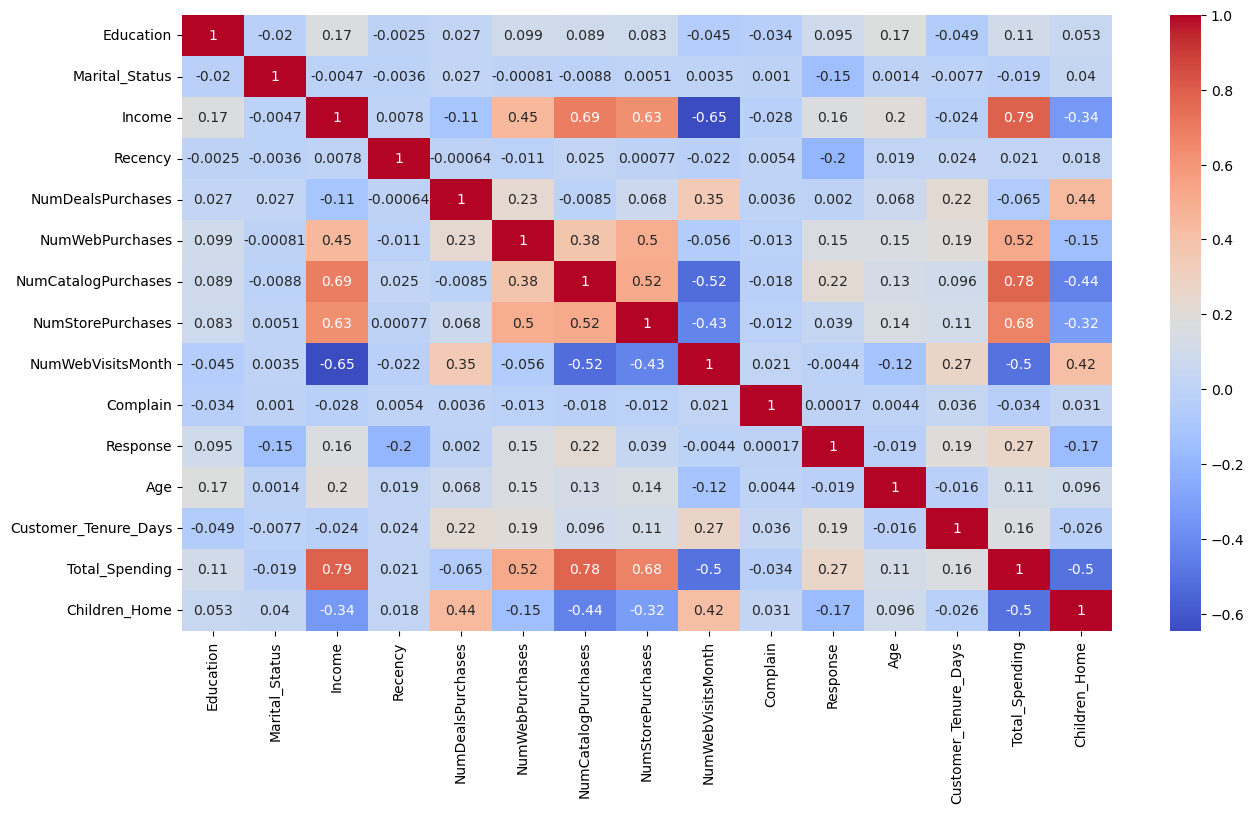

In [190]:
fig, axis = plt.subplots(figsize=(15, 8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    ax=axis
)



### Scaling

In [191]:
scaler = StandardScaler().set_output(transform="pandas")
X_scaled = scaler.fit_transform(X_engineered)

### Visualization

In [192]:
tnse = TSNE(
    n_components=3,
    random_state=42
)

X_tsne = tnse.fit_transform(X_scaled)

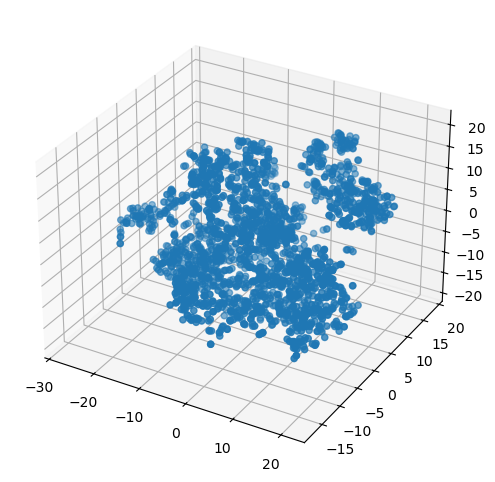

In [193]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(
    111, projection="3d"
)

ax.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    X_tsne[:, 2]
)

# Model training Without PCA

## K Means

### Elbow Method & Silhoutte score

In [194]:
k_range = range(2, 11)
wcss = []
ss = []

for k in k_range:
    km_model = KMeans(n_clusters=k, random_state=42)
    labels = km_model.fit_predict(X_scaled)
    wcss.append(km_model.inertia_)
    ss.append(silhouette_score(X_scaled, labels))

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Text(0.5, 1.0, 'Elbow Plot')

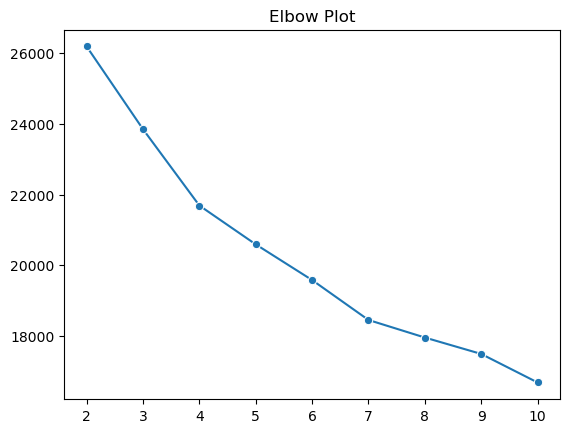

In [195]:
sns.lineplot(
    x=k_range,
    y=wcss,
    marker="o"
)

plt.title("Elbow Plot")

In [196]:
knee_locator = KneeLocator(
    x=k_range,
    y=wcss,
    curve="convex",
    direction="decreasing"
)

knee_locator.elbow

np.int64(4)

Elbow method wasn't quite stable. It changed K value based on range provided.





Text(0.5, 1.0, 'Silhoutte Score plot')

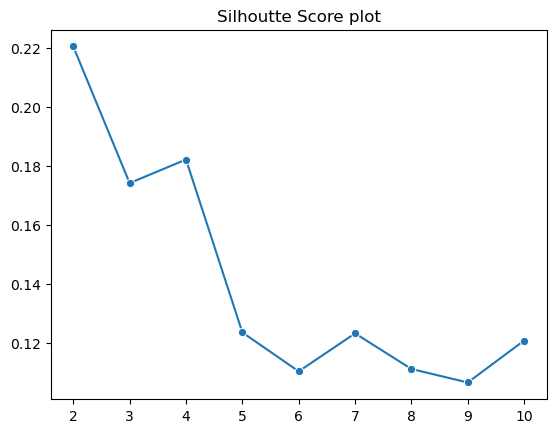

In [197]:
sns.lineplot(
    x=k_range,
    y=ss,
    marker="o"
)
plt.title("Silhoutte Score plot")


Text(0, 0.5, 'SS')

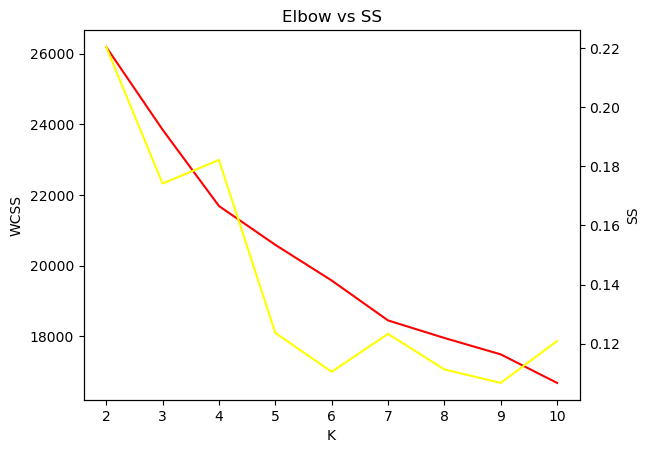

In [198]:
fig, axis1 = plt.subplots()

axis1.plot(k_range, wcss, color="red")
axis1.set_title("Elbow vs SS")
axis1.set_xlabel("K")
axis1.set_ylabel("WCSS")

axis2 = axis1.twinx()
axis2.plot(k_range, ss, color="yellow")
axis2.set_ylabel("SS")

Overall We will choose 4 as optimal K as it is suggested by Elbow method and also holds good value on Silhoutte score

## Training & Evaluation

In [199]:
km_model = KMeans(
    n_clusters=4,
    random_state=42,
)
km_labels = km_model.fit_predict(X_scaled)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


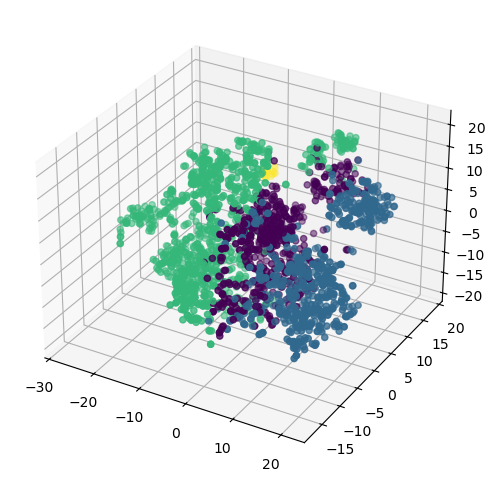

In [200]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(
    111, projection="3d"
)

ax.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    X_tsne[:, 2],
    c=km_labels
)

In [201]:
print("Silhoutte score:", silhouette_score(X_scaled, km_labels))
print("Davies Boulding score:", davies_bouldin_score(X_scaled, km_labels))

Silhoutte score: 0.18215250244226866
Davies Boulding score: 1.6483962403258934


## Agglomerative Clustering

### Optimal value of K

In [202]:
Z = linkage(X_scaled, method="ward")

Text(0, 0.5, 'Distances')

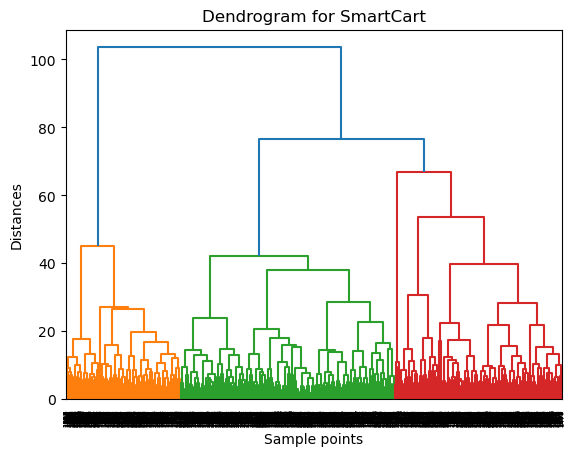

In [203]:
dendrogram(Z)
plt.title("Dendrogram for SmartCart")
plt.xlabel("Sample points")
plt.ylabel("Distances")

### Training and Evaluation

In [204]:
ac_model = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward",
)
ac_labels = ac_model.fit_predict(X_scaled)

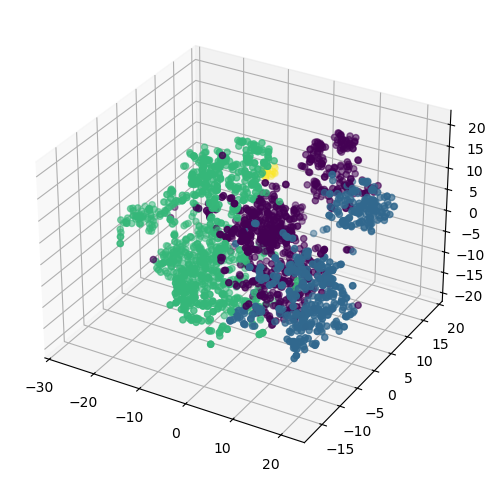

In [205]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(
    111, projection="3d"
)

ax.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    X_tsne[:, 2],
    c=ac_labels
)

In [206]:
print("Silhoutte score:", silhouette_score(X_scaled, ac_labels))
print("Davies Boulding score:", davies_bouldin_score(X_scaled, ac_labels))

Silhoutte score: 0.15162883202297156
Davies Boulding score: 1.8486437216062213


## DBSCAN

### Training and Evaluation

In [207]:
dbscan_model = DBSCAN(
    min_samples=16,
    eps=2
)
dbscan_labels = dbscan_model.fit_predict(X_scaled)

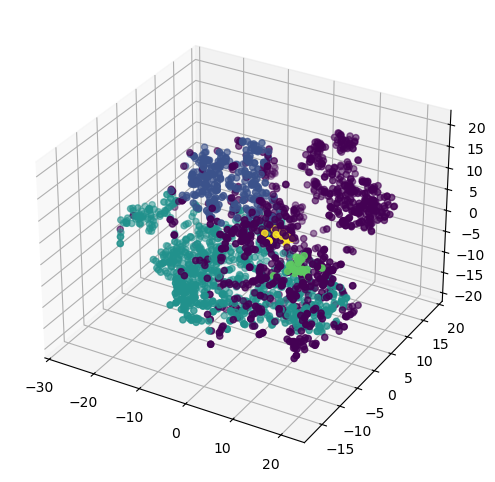

In [208]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(
    111, projection="3d"
)

ax.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    X_tsne[:, 2],
    c=dbscan_labels
)

In [209]:
print("Silhoutte score:", silhouette_score(X_scaled, dbscan_labels))
print("Davies Boulding score:", davies_bouldin_score(X_scaled, dbscan_labels))

Silhoutte score: -0.0879670010807582
Davies Boulding score: 2.554223085704121


Based on Silhoutte score and Daives Bouldin score value, KMeans seems a more suitable choice for clustering.

# Interpretation

In [210]:
X_engineered.iloc[192]

Education                   1.0
Marital_Status              1.0
Income                  38872.0
Recency                    93.0
NumDealsPurchases           2.0
NumWebPurchases             3.0
NumCatalogPurchases         0.0
NumStorePurchases           3.0
NumWebVisitsMonth           8.0
Complain                    0.0
Response                    0.0
Age                        38.0
Customer_Tenure_Days     4802.0
Total_Spending             91.0
Children_Home               1.0
Name: 192, dtype: float64

In [211]:
X_labelled = pd.concat(
    [
        X_engineered,
        pd.DataFrame(ac_labels, columns=["Cluster"])
    ],
    axis=1
)

In [212]:
X_labelled["Cluster"].value_counts()

Cluster
2    967
0    731
1    518
3     20
Name: count, dtype: int64

C:\Users\User\AppData\Local\Temp\ipykernel_14748\1576651123.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


<Axes: xlabel='Cluster', ylabel='count'>

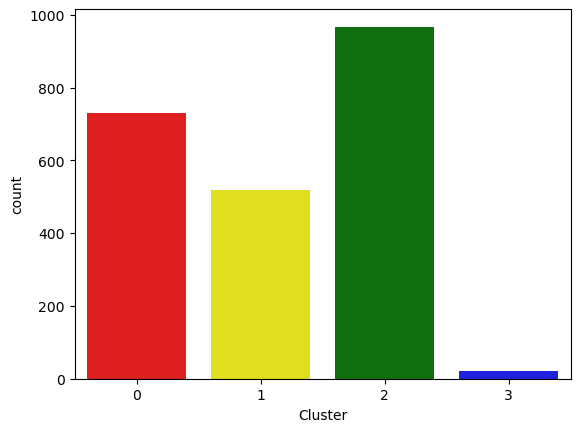

In [213]:
palatte = ["red", "yellow", "green", "blue"]

sns.countplot(
    data=X_labelled,
    x="Cluster",
    palette=palatte
)

In [214]:
print(X_labelled.groupby("Cluster").mean())

         Education  Marital_Status        Income    Recency  \
Cluster                                                       
0         1.091655        0.637483  54795.430917  44.703146   
1         1.185328        0.588803  76039.805985  50.527027   
2         1.071355        0.680455  37030.524819  51.662875   
3         0.900000        0.650000  45672.400000  50.750000   

         NumDealsPurchases  NumWebPurchases  NumCatalogPurchases  \
Cluster                                                            
0                 3.694938         5.945280             2.835841   
1                 1.237452         4.870656             6.187259   
2                 1.872802         2.271975             0.656670   
3                 2.400000         3.700000             2.100000   

         NumStorePurchases  NumWebVisitsMonth  Complain  Response        Age  \
Cluster                                                                        
0                 7.095759           6.153215       